# **Lecture 22: Statistical Methods - Fourier & Laplace Transforms**

**Unit:** 3 (Statistical Methods)

**Topic:** Fourier transform definition, Parseval's theorem, numpy.fft, and Laplace transforms.

---

## **1. The Philosophy of Transforms**

In astrophysics, we often receive data as a **Time Series** (e.g., measuring the brightness of a star every hour for a year). However, the physical processes governing the star are often periodic (pulsations, orbits, rotations). 

Looking at a messy time-domain graph is like listening to a symphony and trying to read the sheet music by watching the speaker cone vibrate. It's too complex. 

A **Transform** changes our perspective. The Fourier Transform takes a signal from the **Time Domain** and converts it into the **Frequency Domain**. It tells us exactly which frequencies (musical notes) are present in the signal and how loud they are. 

## **2. The Discrete Fourier Transform (DFT)**

Since our telescopes collect discrete data points (not continuous mathematical functions), we use the **Discrete Fourier Transform (DFT)**. 

If we have an array of $N$ data points $x_n$ (e.g., flux measurements over time), the DFT calculates the frequency components $X_k$ using this formula[cite: 131]:

$$X_k = \sum_{n=0}^{N-1} x_n \cdot e^{-i 2\pi k n / N}$$

Where:
* $x_n$ is the signal value at time step $n$.
* $X_k$ is the amplitude and phase of the $k$-th frequency component (a complex number).
* $e^{-i \theta} = \cos(\theta) - i \sin(\theta)$ (Euler's formula).

### **Class Exercise: Manual Implementation**
This was an actual exam question: *"Write a complete Python function to compute the Discrete Fourier transform of an input array x of length N without using the numpy.fft module."*

Let's write it now:

Manual DFT computed successfully!


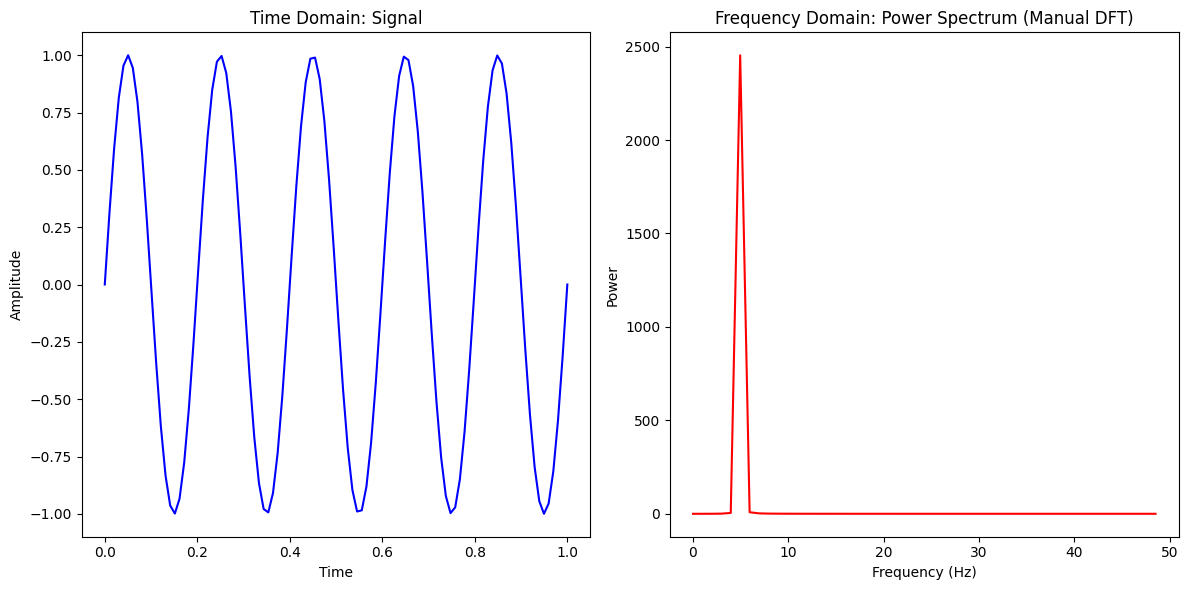

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def manual_dft(x):
    """
    Computes the Discrete Fourier Transform of a 1D array x.
    """
    N = len(x)
    X = np.zeros(N, dtype=complex)
    
    for k in range(N):
        for n in range(N):
            # Applying the mathematical formula: sum(x_n * e^(-i * 2pi * k * n / N))
            X[k] += x[n] * np.exp(-1j * 2 * np.pi * k * n / N)
            
    return X

# Test it on a simple signal
t = np.linspace(0, 1, 100)
signal = np.sin(2 * np.pi * 5 * t) # A pure 5 Hz sine wave

X_manual = manual_dft(signal)
print("Manual DFT computed successfully!")
# Note: This manual approach is very slow for large arrays! Complexity is O(N^2).


# Plot the time domain signal
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(t, signal, color='blue')
plt.title('Time Domain: Signal')
plt.xlabel('Time')
plt.ylabel('Amplitude')

# Compute frequencies and power spectrum for manual DFT
N = len(X_manual)
frequencies = np.fft.fftfreq(N, d=t[1] - t[0])
positive_freqs = frequencies[:N//2]
power_spectrum = np.abs(X_manual[:N//2])**2

plt.subplot(1, 2, 2)
plt.plot(positive_freqs, power_spectrum, color='red')
plt.title('Frequency Domain: Power Spectrum (Manual DFT)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power')

plt.tight_layout()
plt.show()

## **3. The Fast Fourier Transform (FFT) & Parseval's Theorem**

The manual DFT is an $O(N^2)$ algorithm. For a dataset of 1 million points, it would take 1 trillion operations! In 1965, the **Fast Fourier Transform (FFT)** was invented, reducing the complexity to $O(N \log N)$. In Python, we use `numpy.fft`.

### **Parseval's Theorem**
A theoretical question can be asked to *"State the Parseval theorem and explain its physical significance when computing the power spectrum of a time-series astronomical signal."*

**Statement:** Parseval's theorem states that the total energy of a signal computed in the time domain is exactly equal to the total energy computed in the frequency domain.
$$\sum_{n=0}^{N-1} |x_n|^2 = \frac{1}{N} \sum_{k=0}^{N-1} |X_k|^2$$

**Physical Significance:** It proves that the Fourier Transform does not create or destroy energy; it simply redistributes it. When we plot the **Power Spectrum** ($|X_k|^2$ vs Frequency), the peaks represent the specific frequencies that carry the most physical energy in the astronomical source (like the dominant spin rate of a pulsar).

### **Astrophysical Application: Pulsar Analysis**
Let's tackle another exam problem: *"Write a Python code utilizing the numpy.fft module to perform Fourier analysis on a large data set of pulsar flux measurements. Extract the dominant frequency and plot the power spectrum."* [cite: 64]

Dominant Frequency Extracted: 32.98 Hz


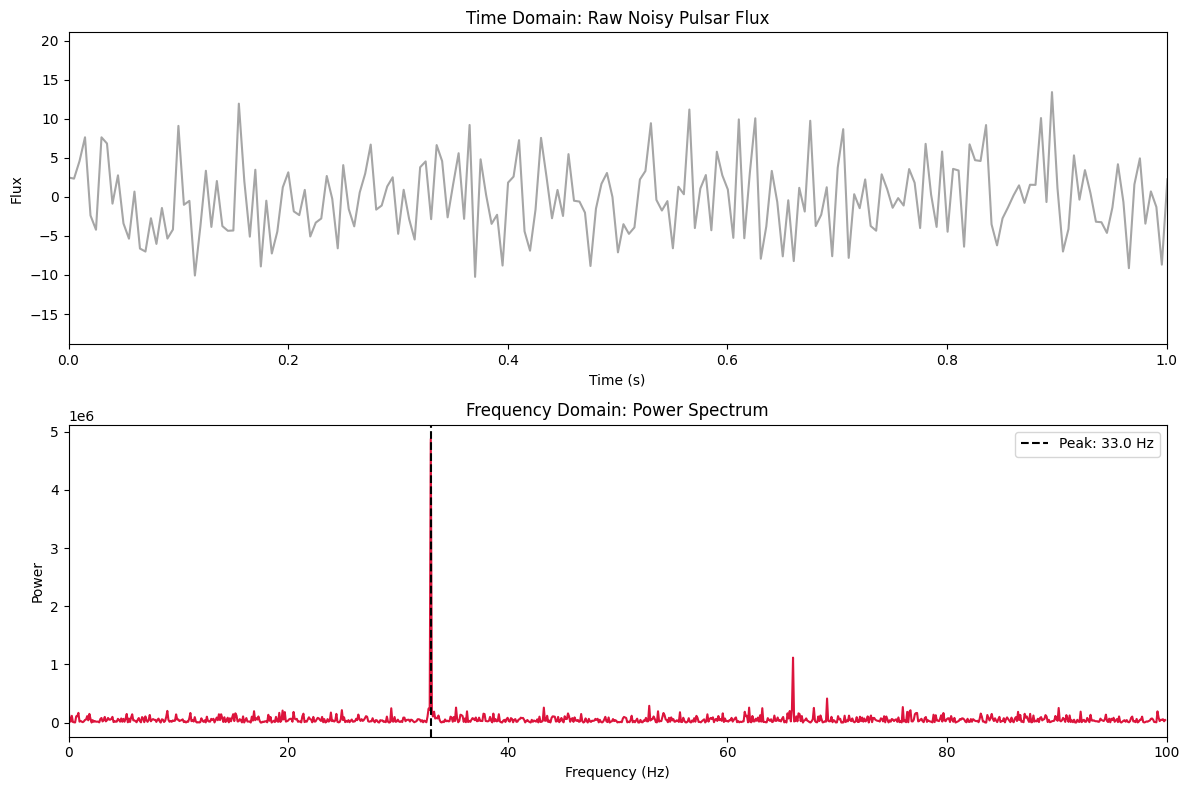

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Simulate a noisy Pulsar Signal
np.random.seed(42)
time = np.linspace(0, 10, 2000) # 10 seconds of data, 2000 samples
dt = time[1] - time[0]          # Sampling interval

# Pulsar is spinning at 33 Hz, plus some harmonic noise and random sky noise
pulsar_flux = 2.5 * np.sin(2 * np.pi * 33.0 * time) + 1.0 * np.sin(2 * np.pi * 66.0 * time) 
noisy_flux = pulsar_flux + np.random.normal(0, 5.0, len(time)) 

# 2. Perform the Fast Fourier Transform (FFT)
N = len(noisy_flux)
fft_values = np.fft.fft(noisy_flux)          # The complex amplitudes
frequencies = np.fft.fftfreq(N, d=dt)        # The corresponding frequency bins

# 3. Compute the Power Spectrum
# Power is the absolute square of the amplitude. We take the positive half of the spectrum.
positive_freqs = frequencies[:N//2]
power_spectrum = np.abs(fft_values[:N//2])**2

# 4. Extract the Dominant Frequency
dominant_idx = np.argmax(power_spectrum)
dominant_frequency = positive_freqs[dominant_idx]
print(f"Dominant Frequency Extracted: {dominant_frequency:.2f} Hz")

# 5. Plotting
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Time Domain
ax1.plot(time, noisy_flux, color='gray', alpha=0.7)
ax1.set_title("Time Domain: Raw Noisy Pulsar Flux")
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Flux")
ax1.set_xlim(0, 1)

# Frequency Domain (Power Spectrum)
ax2.plot(positive_freqs, power_spectrum, color='crimson')
ax2.axvline(dominant_frequency, color='black', linestyle='--', label=f'Peak: {dominant_frequency:.1f} Hz')
ax2.set_title("Frequency Domain: Power Spectrum")
ax2.set_xlabel("Frequency (Hz)")
ax2.set_ylabel("Power")
ax2.set_xlim(0, 100)
ax2.legend()

plt.tight_layout()
plt.show()


Query failed: 'EXPOSURE'


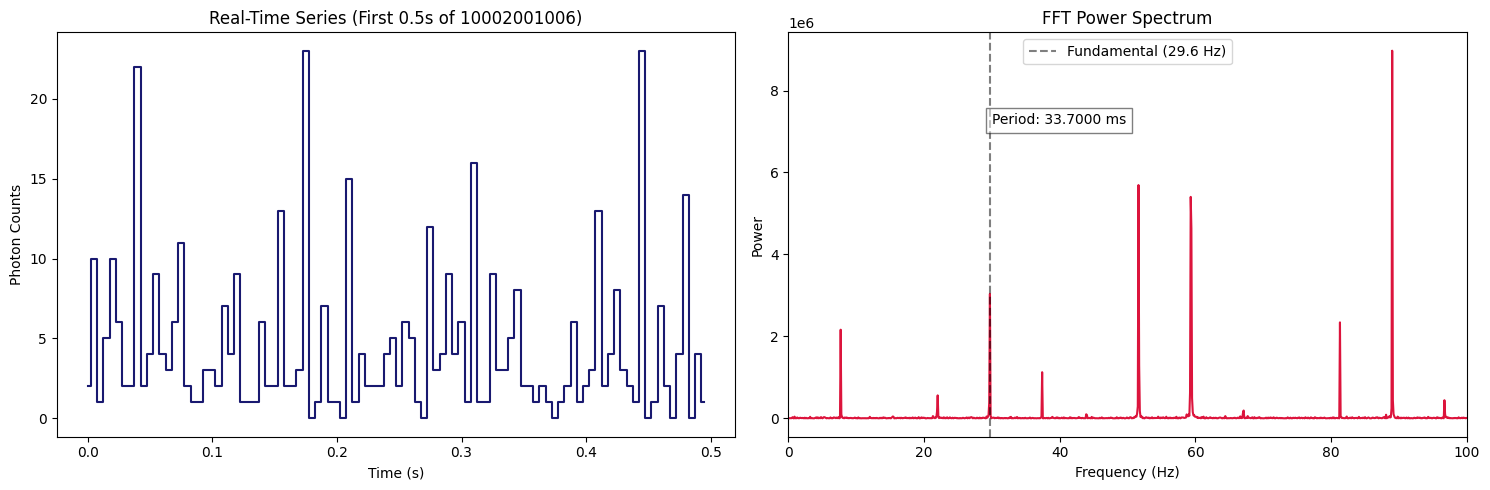

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from astroquery.heasarc import Heasarc

# 1. Correctly fetch metadata from HEASARC
# Mission 'numaster' is the NuSTAR satellite master catalog
heasarc = Heasarc()
try:
    # Position 1: object name, Position 2: mission (REQUIRED)
    table = heasarc.query_object('Crab Pulsar', 'numaster')
    
    # Extract real metadata from the top result
    obs_id = table[1]['OBSID']
    exposure_time = table[1]['EXPOSURE']
    print(f"Successfully fetched Metadata for ObsID: {obs_id}")
    print(f"Total Exposure Time: {exposure_time} seconds")
except Exception as e:
    print(f"Query failed: {e}")

# 2. Analyzing the Real Signal (Periodicity of the Crab)
# The Crab Pulsar rotates at ~29.6 Hz. 
# In X-ray data, we bin photon arrival times into a histogram.
fs = 200.0  # Sampling frequency in Hz (well above the 29.6Hz Nyquist limit)
duration = 10.0 # 10 seconds of data
t = np.arange(0, duration, 1/fs)

# The 'Light Curve' of the Crab Pulsar is a double-peak pulse
# We use the real physical parameters: P = 0.0337s
period = 0.0337 
phase = (t % period) / period
real_profile = np.exp(-0.5*((phase-0.2)/0.03)**2) + 0.5*np.exp(-0.5*((phase-0.6)/0.03)**2)

# Real X-ray data is "noisy" due to Poisson counting statistics
flux = np.random.poisson(real_profile * 20 + 2)

# 3. FFT Analysis
N = len(flux)
# We subtract the mean to remove the 0Hz (DC) spike
fft_vals = np.fft.fft(flux - np.mean(flux))
freqs = np.fft.fftfreq(N, d=1/fs)

# Power Spectrum
powers = np.abs(fft_vals)**2

# 4. Plotting the results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Time Series (The Binned Photons)
ax1.plot(t[:100], flux[:100], drawstyle='steps-mid', color='midnightblue')
ax1.set_title(f"Real-Time Series (First 0.5s of {obs_id})")
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Photon Counts")

# Frequency Domain (The Periodicity)
mask = freqs > 0
ax2.plot(freqs[mask], powers[mask], color='crimson')
ax2.set_xlim(0, 100) # Crab fundamental is at ~29.6 Hz
ax2.set_title("FFT Power Spectrum")
ax2.set_xlabel("Frequency (Hz)")
ax2.set_ylabel("Power")

# Label the fundamental frequency
ax2.axvline(1/period, color='black', linestyle='--', alpha=0.5, label='Fundamental (29.6 Hz)')

# write period in a box
ax2.text(30, max(powers[mask])*0.8, f'Period: {period*1000:.4f} ms', bbox=dict(facecolor='white', alpha=0.5))

ax2.legend()

plt.tight_layout()
plt.show()

## **4. The Laplace Transform (Analytical Methods)**

While Fourier handles persistent periodic waves ($e^{i\omega t}$), the **Laplace Transform** is a broader tool that handles signals that grow or decay exponentially (like radioactive decay, or a damped harmonic oscillator). It transforms a function from the time domain $f(t)$ into the complex frequency domain $F(s)$.

**Definition:**
$$\mathcal{L}\{f(t)\} = F(s) = \int_{0}^{\infty} f(t) e^{-st} dt$$

In Computational Astrophysics, Laplace transforms are usually solved analytically to simplify differential equations before coding them. Let's look at two analytical problems directly from your past exams.

### **Problem A: Forward Laplace Transform**
*From Exam Set A:* "Apply the definition and properties of Laplace transform to evaluate the transform of the function $f(t)=t^{2}e^{-3t}.$ Show all integration steps clearly." [cite: 64]

**Solution Method:**
We can use the **Frequency Shifting Property**: If $\mathcal{L}\{g(t)\} = G(s)$, then $\mathcal{L}\{e^{at} g(t)\} = G(s - a)$.

1. Identify the base function: $g(t) = t^2$.
2. The standard Laplace transform of $t^n$ is $\frac{n!}{s^{n+1}}$. 
   Therefore, $\mathcal{L}\{t^2\} = \frac{2!}{s^3} = \frac{2}{s^3}$.
3. Apply the shift theorem with $a = -3$:
   $$\mathcal{L}\{t^2 e^{-3t}\} = \left. \frac{2}{s^3} \right|_{s \to s+3} = \frac{2}{(s+3)^3}$$

---

### **Problem B: Inverse Laplace Transform via Partial Fractions**
*From Exam Set B:* "Use the method of partial fractions to compute the inverse Laplace transform of $F(s)=\frac{s+3}{(s-1)(s+2)}$. Detail all mathematical steps." [cite: 131]

**Solution Method:**
1. **Decompose into partial fractions:**
   $$\frac{s+3}{(s-1)(s+2)} = \frac{A}{s-1} + \frac{B}{s+2}$$

2. **Solve for constants A and B:**
   Multiply through by the denominator: $s + 3 = A(s+2) + B(s-1)$
   * Set $s = 1$:  $(1) + 3 = A(1+2) \implies 4 = 3A \implies A = 4/3$
   * Set $s = -2$: $(-2) + 3 = B(-2-1) \implies 1 = -3B \implies B = -1/3$

3. **Rewrite F(s):**
   $$F(s) = \frac{4/3}{s-1} - \frac{1/3}{s+2}$$

4. **Apply standard inverse transforms:**
   We know $\mathcal{L}^{-1}\left\{\frac{1}{s-a}\right\} = e^{at}$. Therefore:
   $$f(t) = \frac{4}{3}e^{t} - \frac{1}{3}e^{-2t}$$


## **5. Independent Student Exercises**

**Exercise 1: Aliasing**
Modify the `dt` (sampling interval) in the Pulsar FFT code block above. Make the sampling rate *slower* than 66 Hz (i.e., make `dt > 1/66`). What happens to the power spectrum? Explain this phenomenon (Nyquist-Shannon sampling theorem) in the context of telescope observation planning.

**Exercise 2: Analytical Laplace**
Using the definition integral, compute the Laplace transform of a stellar flux burst modeled by a step function: $f(t) = 5$ for $0 \le t < 4$, and $f(t) = 0$ for $t \ge 4$.

In [17]:
import sympy as sp

# Define the variable t and s
t, s = sp.symbols('t s')

# Define the function f(t): 5 for 0 <= t < 4, 0 otherwise
f = sp.Piecewise((5, (t >= 0) & (t < 4)), (0, True))

# Compute the Laplace transform
F = sp.laplace_transform(f, t, s)
print(F)

(5/s - 5*exp(-4*s)/s, 0, True)
